# YOLOv2 Practical Notebook — 2016

**No live inference in this notebook.** Like v1, original YOLOv2/YOLO9000 Darknet weights aren't reliably available anymore. This is a comparison-only notebook using verified published benchmarks, plus one illustrative (not real-model) visualization of the anchor-box concept.

### What's new vs. v1 (verified ablation study, VOC 2007)

| Change added | Resulting mAP |
|---|---|
| Baseline (YOLOv1) | 63.4% |
| + Batch Normalization | 65.8% |
| + High-Res Classifier pretraining | 69.5% |
| + Anchor boxes (raw) | 69.2% (slight dip, but recall jumped 81%->88%) |
| + Dimension priors (k-means anchors) | 69.6% |
| + Direct location prediction (sigmoid constraint) | 74.4% |
| + Passthrough layer | 75.4% |
| + Multi-scale training | 78.6% |

Backbone: Darknet-19 (fully convolutional, no FC layers -- fixes v1's spatial-structure-destroying FC layers), only 5.58 BFLOPs vs VGG-16's 30.95.

### Illustrative visualization: anchor box shapes (NOT a real trained model)

This shows what anchor boxes conceptually look like relative to an image -- illustrative shapes, not genuine k-means output on a real dataset.

'wget' is not recognized as an internal or external command,
operable program or batch file.


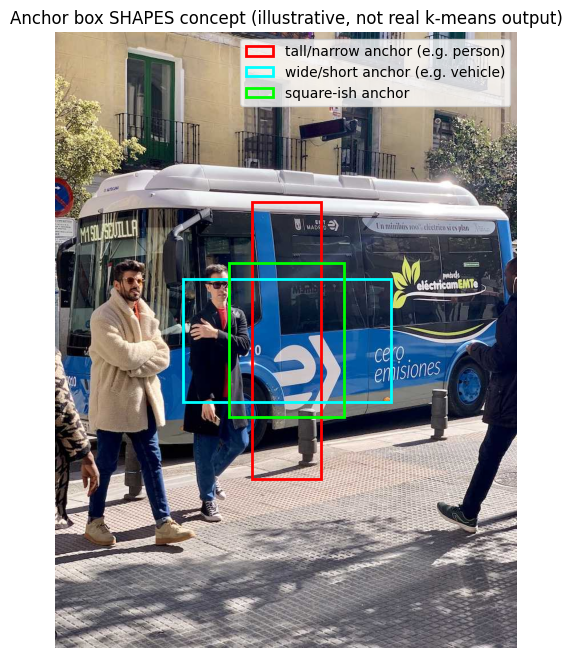

In [1]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

!wget -q https://ultralytics.com/images/bus.jpg -O bus.jpg

img = cv2.cvtColor(cv2.imread('bus.jpg'), cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# Illustrative anchor shapes (NOT real k-means output) just to show the concept:
# one tall/narrow (person-like), one wide/short (vehicle-like), one square-ish
anchors = [
    (0.15 * w, 0.45 * h, 'tall/narrow anchor (e.g. person)'),
    (0.45 * w, 0.20 * h, 'wide/short anchor (e.g. vehicle)'),
    (0.25 * w, 0.25 * h, 'square-ish anchor'),
]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
colors = ['red', 'cyan', 'lime']
cx, cy = w * 0.5, h * 0.5  # just centering all anchors at the same point for comparison
for (aw, ah, label), color in zip(anchors, colors):
    rect = patches.Rectangle((cx - aw/2, cy - ah/2), aw, ah, linewidth=2, edgecolor=color, facecolor='none', label=label)
    ax.add_patch(rect)
ax.legend(loc='upper right')
ax.set_title("Anchor box SHAPES concept (illustrative, not real k-means output)")
ax.axis('off')
plt.show()


### One-line takeaway

v2's anchor boxes gave the network shape priors to adjust instead of predicting boxes from scratch, and its ablation study proves each individual fix (batch norm, anchors, multi-scale training) contributed measurably to the final accuracy gain.